In [1]:
import os
import re
import sys
import json
import torch
import numpy as np
import seaborn as sns
from tqdm import tqdm
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import torch.nn.functional as F
from sklearn.metrics import roc_auc_score

In [2]:
def parse_dataset_name(folder_name):
    pattern1 = r'De-noised_(\d+)G_(\d+)T_(\d+)cPerT_dynamics_(\d+)_DS(\d+)'
    pattern2 = r'De-noised_(\d+)G_(\d+)T_(\d+)cPerT_(\d+)_DS(\d+)'
    match_p1 = re.match(pattern1, folder_name)
    match_p2 = re.match(pattern2, folder_name)
    if match_p1:
        return {
            'number_genes': int(match_p1.group(1)),
            'number_bins': int(match_p1.group(2)),
            'cells_per_type': int(match_p1.group(3)),
            'dynamics': int(match_p1.group(4)),
            'dataset_id': int(match_p1.group(5)),
            'folder_name': folder_name
        }
    if match_p2:
        return {
            'number_genes': int(match_p2.group(1)),
            'number_bins': int(match_p2.group(2)),
            'cells_per_type': int(match_p2.group(3)),
            'dynamics': int(match_p2.group(4)),
            'dataset_id': int(match_p2.group(5)),
            'folder_name': folder_name
        }
    return

def get_datasets():
    datasets = []
    data_sets_dir = '../SERGIO/data_sets'
    for folder_name in os.listdir(data_sets_dir):
        dataset_info = parse_dataset_name(folder_name)
        if dataset_info:
            datasets.append(dataset_info)
    return sorted(datasets, key=lambda x: x['dataset_id'])

def load_data(dataset_info):
    dataset_id = dataset_info['dataset_id']
    data_dir = f'../SERGIO/imputation_data_2/DS{dataset_id}/'
    ds_clean_path = os.path.join(data_dir, 'DS6_clean.npy')
    ds_noisy_path = os.path.join(data_dir, 'DS6_45_iter_0.npy')
    if not os.path.exists(ds_clean_path) or not os.path.exists(ds_noisy_path):
        print(f"Data files not found for Dataset {dataset_id}. Skipping.")
        return None, None
    ds_clean = np.load(ds_clean_path).astype(np.float32)
    ds_noisy = np.load(ds_noisy_path).astype(np.float32)
    return ds_clean, ds_noisy

def load_interactions_info(num_genes, interactions_file):
    gt = np.zeros((num_genes, num_genes))
    with open(interactions_file, 'r') as f:
        lines = f.readlines()
    for line in lines:
        line_list = line.strip().split(',')
        target_index = int(float(line_list[0]))
        num_regs = int(float(line_list[1]))
        for i in range(num_regs):
            try:
                reg_index = int(float(line_list[i + 2]))
                gt[reg_index, target_index] = 1
            except:
                continue
    return gt

In [3]:
def load_ground_truth_grn(file_path, num_genes):
    H = np.zeros((num_genes, num_genes))
    with open(file_path, 'r') as f:
        for line in f:
            source, target = map(int, line.strip().split(','))
            H[source, target] = 1
    return H

def sample_partial_grn(H, sample_ratio=8/10):
    num_edges = np.sum(H)
    num_sample = int(num_edges * sample_ratio)
    edge_indices = np.argwhere(H == 1)
    np.random.shuffle(edge_indices)
    sampled_edges = edge_indices[:num_sample]
    G = np.zeros_like(H)
    G[tuple(zip(*sampled_edges))] = 1
    return G

def split_train_valid(G, train_ratio=7/8):  # 7:1 ratio
    edge_indices = np.argwhere(G == 1)
    num_edges = len(edge_indices)
    num_train = int(num_edges * train_ratio)
    np.random.shuffle(edge_indices)
    train_edges = edge_indices[:num_train]
    valid_edges = edge_indices[num_train:]
    G_train = np.zeros_like(G)
    G_valid = np.zeros_like(G)
    G_train[tuple(zip(*train_edges))] = 1
    G_valid[tuple(zip(*valid_edges))] = 1
    return G_train, G_valid

def get_test_set(H, G):
    G_test = H - G
    G_test[G_test < 0] = 0
    return G_test

In [4]:
def generate_balanced_batches(embeddings, adjacency_matrix, batch_size, num_batches):
    num_nodes = embeddings.shape[0]
    positive_edges = np.argwhere(adjacency_matrix == 1)
    negative_edges = np.argwhere(adjacency_matrix == 0)
    
    np.random.shuffle(positive_edges)
    np.random.shuffle(negative_edges)
    
    for i in range(num_batches):
        start_idx = i * batch_size
        end_idx = min((i + 1) * batch_size, len(positive_edges))
        
        batch_positive = positive_edges[start_idx:end_idx]
        batch_negative = negative_edges[np.random.choice(len(negative_edges), size=len(batch_positive), replace=False)]

        batch_edges = np.concatenate([batch_positive, batch_negative])
        batch_labels = np.concatenate([np.ones(len(batch_positive)), np.zeros(len(batch_negative))])
        
        # Shuffle the batch
        shuffle_idx = np.random.permutation(len(batch_edges))
        batch_edges = batch_edges[shuffle_idx]
        batch_labels = batch_labels[shuffle_idx]
        
        x1 = torch.tensor(embeddings[batch_edges[:, 0]], dtype=torch.float32)
        x2 = torch.tensor(embeddings[batch_edges[:, 1]], dtype=torch.float32)
        labels = torch.tensor(batch_labels, dtype=torch.float32)
        yield x1, x2, labels

def generate_batches(embeddings, adjacency_matrix, batch_size, num_batches, negative_ratio=10):
    positive_edges = np.argwhere(adjacency_matrix == 1)
    negative_edges = np.argwhere(adjacency_matrix == 0)
    np.random.shuffle(positive_edges)
    np.random.shuffle(negative_edges)
    for i in range(num_batches):
        start_idx = i * batch_size
        end_idx = min((i + 1) * batch_size, len(positive_edges))
        batch_positive = positive_edges[start_idx:end_idx]
        num_negatives = len(batch_positive) * negative_ratio
        batch_negative = negative_edges[np.random.choice(len(negative_edges), size=num_negatives, replace=False)]
        batch_edges = np.concatenate([batch_positive, batch_negative])
        batch_labels = np.concatenate([np.ones(len(batch_positive)), np.zeros(len(batch_negative))])
        # Shuffle the batch
        shuffle_idx = np.random.permutation(len(batch_edges))
        batch_edges = batch_edges[shuffle_idx]
        batch_labels = batch_labels[shuffle_idx]
        x1 = torch.tensor(embeddings[batch_edges[:, 0]], dtype=torch.float32)
        x2 = torch.tensor(embeddings[batch_edges[:, 1]], dtype=torch.float32)
        labels = torch.tensor(batch_labels, dtype=torch.float32)
        yield x1, x2, labels

In [5]:
class ContrastiveModel(nn.Module):
    def __init__(self, input_dim, projection_dim):
        super(ContrastiveModel, self).__init__()
        self.projection = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Linear(256, projection_dim)
        )
    
    def forward(self, x1, x2):
        proj1 = self.projection(x1)
        proj2 = self.projection(x2)
        return proj1, proj2

In [6]:
# class SoftNearestNeighborLoss(nn.Module):
#     def __init__(self, temperature=0.5):
#         super(SoftNearestNeighborLoss, self).__init__()
#         self.temperature = temperature

#     def forward(self, embeddings, labels):
#         """
#         embeddings: Tensor of shape [batch_size * 2, projection_dim]
#         labels: Tensor of shape [batch_size * 2]
#         """
#         batch_size = embeddings.size(0)
#         embeddings = nn.functional.normalize(embeddings, p=2, dim=1)
#         sim_matrix = torch.matmul(embeddings, embeddings.T) / self.temperature  # [batch_size*2, batch_size*2]
#         if torch.isnan(sim_matrix).any():
#             print("NaN detected in sim_matrix")
#         mask = torch.eye(batch_size, device=embeddings.device).bool()
#         if torch.isnan(mask).any():
#             print("NaN detected in mask")
#         sim_matrix = sim_matrix.masked_fill(mask, -float('inf'))
#         if torch.isnan(sim_matrix).any():
#             print("NaN detected in sim_matrix after masking")
#         sim_exp = torch.exp(sim_matrix)
#         if torch.isnan(sim_exp).any():
#             print("NaN detected in sim_exp")
#         sim_exp_sum = sim_exp.sum(dim=1, keepdim=True)
#         if torch.isnan(sim_exp_sum).any():
#             print("NaN detected in sim_exp_sum")
#         # print(sim_matrix)
#         sim_probs = sim_exp / (sim_exp_sum + 1)
#         if torch.isnan(sim_probs).any():
#             print("NaN detected in sim_probs")
#         labels = labels.unsqueeze(1)
#         if torch.isnan(labels).any():
#             print("NaN detected in labels")
#         label_equal = labels == labels.T
#         if torch.isnan(label_equal).any():
#             print("NaN detected in label_equal")
#         loss = -torch.log((sim_probs * label_equal.float()).sum(dim=1) + 1e-8)
#         if torch.isnan(loss).any():
#             print("NaN detected in loss")
#         return loss.mean()

# def train_snn(embeddings, adjacency_matrix, input_dim, projection_dim, num_epochs, batch_size, learning_rate, device):
#     model = ContrastiveModel(input_dim, projection_dim).to(device)
#     optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
#     criterion = SoftNearestNeighborLoss(temperature=0.5)
    
#     num_positive_edges = len(np.argwhere(adjacency_matrix == 1))
#     num_batches = num_positive_edges // batch_size
#     print("num_positive_edges: ", num_positive_edges, num_batches)
    
#     for epoch in range(num_epochs):
#         total_loss = 0
#         model.train()
#         for x1, x2, labels in generate_balanced_batches(embeddings, adjacency_matrix, batch_size, num_batches):
#             x1, x2, labels = x1.to(device), x2.to(device), labels.to(device)
#             optimizer.zero_grad()
#             proj1, proj2 = model(x1, x2)
#             # combine projections and labels for loss computation
#             embeddings_batch = torch.cat([proj1, proj2], dim=0)
#             labels_batch = torch.cat([labels, labels], dim=0)
#             loss = criterion(embeddings_batch, labels_batch)
#             loss.backward()
#             optimizer.step()
#             total_loss += loss.item()
        
#         avg_loss = total_loss / num_batches
#         print(f"Epoch {epoch+1}/{num_epochs}, Loss: {avg_loss:.4f}")
    
#     return model

class SoftNearestNeighborLoss(nn.Module):
    def __init__(self, temperature=100., cos_distance=True):
        super(SoftNearestNeighborLoss, self).__init__()
        self.temperature = temperature
        self.cos_distance = cos_distance

    def pairwise_cos_distance(self, A, B):
        query_embeddings = F.normalize(A, dim=1)
        key_embeddings = F.normalize(B, dim=1)
        distances = 1 - torch.matmul(query_embeddings, key_embeddings.T)
        return distances

    def forward(self, embeddings, labels):
        """
        Args:
            embeddings: Batched embeddings to compute the SNNL.
            labels: Labels of embeddings.
        """
        batch_size = embeddings.shape[0]
        eps = 1e-9

        if self.cos_distance:
            pairwise_dist = self.pairwise_cos_distance(embeddings, embeddings)
        else:
            pairwise_dist = torch.cdist(embeddings, embeddings, p=2)

        pairwise_dist = pairwise_dist / self.temperature
        negexpd = torch.exp(-pairwise_dist)

        # Creating mask to sample same class neighborhood
        pairs_y = labels.unsqueeze(1).expand(batch_size, batch_size)
        mask = pairs_y == pairs_y.T
        mask = mask.float()

        # Creating mask to exclude diagonal elements
        dmask = 1 - torch.eye(batch_size, device=embeddings.device)

        # All class neighborhood
        alcn = torch.sum(negexpd * dmask, dim=1)

        # Same class neighborhood
        sacn = torch.sum(negexpd * mask, dim=1)

        # Adding eps for numerical stability
        loss = -torch.log((sacn + eps) / alcn).mean()

        return loss

def train_snn(embeddings, adjacency_matrix, input_dim, projection_dim, num_epochs, batch_size, learning_rate, device):
    model = ContrastiveModel(input_dim, projection_dim).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    criterion = SoftNearestNeighborLoss(temperature=1.)
    num_positive_edges = (adjacency_matrix == 1).sum().item()
    num_batches = num_positive_edges // batch_size
    print(f"num_positive_edges: {num_positive_edges}, num_batches: {num_batches}")

    for epoch in range(num_epochs):
        total_loss = 0
        model.train()
        for x1, x2, labels in generate_batches(embeddings, adjacency_matrix, batch_size, num_batches):
            x1, x2, labels = x1.to(device), x2.to(device), labels.to(device)
            optimizer.zero_grad()
            proj1, proj2 = model(x1, x2)
            
            # Combine projections for loss computation
            embeddings_batch = torch.cat([proj1, proj2], dim=0)
            labels_batch = torch.cat([labels, labels], dim=0)
            
            loss = criterion(embeddings_batch, labels_batch)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        avg_loss = total_loss / num_batches
        print(f"Epoch {epoch+1}/{num_epochs}, Loss: {avg_loss:.4f}")
    return model

def train_cl(embeddings, adjacency_matrix, input_dim, projection_dim, num_epochs, batch_size, learning_rate, device):
    model = ContrastiveModel(input_dim, projection_dim).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    margin = 1.0
    num_positive_edges = len(np.argwhere(adjacency_matrix == 1))
    num_batches = num_positive_edges // batch_size
    print("num_positive_edges: ", num_positive_edges, num_batches)
    
    for epoch in range(num_epochs):
        total_loss = 0
        model.train()
        for x1, x2, labels in generate_batches(embeddings, adjacency_matrix, batch_size, num_batches):
            x1, x2, labels = x1.to(device), x2.to(device), labels.to(device).float()
            optimizer.zero_grad()
            proj1, proj2 = model(x1, x2)
            distances = F.pairwise_distance(proj1, proj2)
            loss = torch.mean(labels * distances.pow(2) + (1 - labels) * F.relu(margin - distances).pow(2))
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        
        avg_loss = total_loss / num_batches
        print(f"Epoch {epoch+1}/{num_epochs}, Loss: {avg_loss:.4f}")
    
    return model

def train_bce(embeddings, adjacency_matrix, input_dim, projection_dim, num_epochs, batch_size, learning_rate, device):
    model = ContrastiveModel(input_dim, projection_dim).to(device)
    num_positive = np.sum(adjacency_matrix == 1)
    num_negative = np.sum(adjacency_matrix == 0)
    pos_weight = torch.tensor(num_negative / num_positive).to(device)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

    num_positive_edges = len(np.argwhere(adjacency_matrix == 1))
    num_batches = num_positive_edges // batch_size
    print("num_positive_edges: ", num_positive_edges, num_batches)
    
    for epoch in range(num_epochs):
        total_loss = 0
        model.train()
        for x1, x2, labels in generate_batches(embeddings, adjacency_matrix, batch_size, num_batches):
            x1, x2, labels = x1.to(device), x2.to(device), labels.to(device).float()
            optimizer.zero_grad()
            proj1, proj2 = model(x1, x2)
            proj1 = nn.functional.normalize(proj1, p=2, dim=1)
            proj2 = nn.functional.normalize(proj2, p=2, dim=1)
            sim_scores = torch.sum(proj1 * proj2, dim=1)
            loss = criterion(sim_scores, labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        avg_loss = total_loss / num_batches
        print(f"Epoch {epoch+1}/{num_epochs}, Loss: {avg_loss:.4f}")
    
    return model

def train_cel(embeddings, adjacency_matrix, input_dim, projection_dim, num_epochs, batch_size, learning_rate, device):
    model = ContrastiveModel(input_dim, projection_dim).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    criterion = nn.CosineEmbeddingLoss(margin=0.0)
    
    num_positive_edges = len(np.argwhere(adjacency_matrix == 1))
    num_batches = num_positive_edges // batch_size
    print("num_positive_edges: ", num_positive_edges, num_batches)
    
    for epoch in range(num_epochs):
        total_loss = 0
        model.train()
        for x1, x2, labels in generate_batches(embeddings, adjacency_matrix, batch_size, num_batches):
            x1, x2, labels = x1.to(device), x2.to(device), labels.to(device).float()
            cosine_labels = labels * 2 - 1  # Convert to 1 (similar) and -1 (dissimilar)
            optimizer.zero_grad()
            proj1, proj2 = model(x1, x2)
            # Compute loss
            loss = criterion(proj1, proj2, cosine_labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        
        avg_loss = total_loss / num_batches
        print(f"Epoch {epoch+1}/{num_epochs}, Loss: {avg_loss:.4f}")
    
    return model


In [7]:
def evaluate_contrastive_model(model, embeddings, adjacency_matrix, device):
    model.eval()
    with torch.no_grad():
        embeddings_tensor = torch.tensor(embeddings, dtype=torch.float32).to(device)
        projected_embeddings = model.projection(embeddings_tensor)
        projected_embeddings = nn.functional.normalize(projected_embeddings, p=2, dim=1)
        projected_embeddings = projected_embeddings.cpu().numpy()

        num_nodes = projected_embeddings.shape[0]
        true_labels = []
        predicted_scores = []

        indices = np.triu_indices(num_nodes, k=1)
        batch_size = 1000000
        total_pairs = len(indices[0])
        for start_idx in range(0, total_pairs, batch_size):
            end_idx = min(start_idx + batch_size, total_pairs)
            idx1 = indices[0][start_idx:end_idx]
            idx2 = indices[1][start_idx:end_idx]

            emb1 = projected_embeddings[idx1]
            emb2 = projected_embeddings[idx2]

            similarity_scores = np.sum(emb1 * emb2, axis=1)
            true_labels_batch = adjacency_matrix[idx1, idx2]
            true_labels.extend(true_labels_batch)
            predicted_scores.extend(similarity_scores)

        true_labels = np.array(true_labels)
        predicted_scores = np.array(predicted_scores)
        probabilities = 1 / (1 + np.exp(-predicted_scores))
        auc = roc_auc_score(true_labels, probabilities)
    return true_labels, probabilities, auc


In [8]:
def log_experiment(dataset_id, model, input_dim, output_dim, num_epochs, batch_size, learning_rate,
                   loss_function, embedding_type, train_labels, train_scores, valid_labels, 
                   valid_scores, test_labels, test_scores, train_auc, valid_auc, test_auc):
    base_dir = f'./logs/{embedding_type}_{loss_function}_DS{dataset_id}/'
    os.makedirs(base_dir, exist_ok=True)
    existing_versions = [int(d.split('_')[1]) for d in os.listdir(base_dir) if d.startswith('version_')]
    next_version = max(existing_versions + [0]) + 1
    
    # Create the versioned log directory
    log_dir = os.path.join(base_dir, f'version_{next_version}')
    os.makedirs(log_dir, exist_ok=True)
    
    # Save parameters and results
    params = {
        'dataset_id': dataset_id,
        'input_dim': input_dim,
        'output_dim': output_dim,
        'num_epochs': num_epochs,
        'batch_size': batch_size,
        'learning_rate': learning_rate,
        'loss_function': loss_function,
        'embedding_type': embedding_type,
        'train_auc': train_auc,
        'valid_auc': valid_auc,
        'test_auc': test_auc
    }
    
    with open(os.path.join(log_dir, 'params.json'), 'w') as f:
        json.dump(params, f, indent=4)
    
    def plot_distribution(scores, labels, set_name):
        plt.figure(figsize=(12, 6))
        
        # Convert scores to probabilities if they aren't already
        probabilities = 1 / (1 + np.exp(-scores))
        
        # Plot for negative examples
        sns.kdeplot(probabilities[labels == 0], shade=True, color="skyblue", label="Negative", cut=0)
        
        # Plot for positive examples
        sns.kdeplot(probabilities[labels == 1], shade=True, color="red", label="Positive", cut=0)
        
        plt.title(f'{set_name} Set Predicted Probabilities Distribution')
        plt.xlabel('Predicted Probability')
        plt.ylabel('Density')
        plt.legend()
        
        # Add text with class proportions
        total = len(labels)
        pos_prop = np.sum(labels == 1) / total
        neg_prop = 1 - pos_prop
        plt.text(0.05, 0.95, f"Negative: {neg_prop:.2%}\nPositive: {pos_prop:.2%}", 
                 transform=plt.gca().transAxes, verticalalignment='top')
        
        plt.savefig(os.path.join(log_dir, f'{set_name.lower()}_distribution.png'))
        plt.close()

    plot_distribution(train_scores, train_labels, 'Train')
    plot_distribution(valid_scores, valid_labels, 'Validation')
    plot_distribution(test_scores, test_labels, 'Test')
    
    print(f"Experiment logged in {log_dir}")
    
    return log_dir

: 

In [9]:

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
datasets = get_datasets()
dataset_info = datasets[2]
dataset_id = dataset_info['dataset_id']
print(f"\nProcessing Dataset {dataset_id}...")
ds_clean, ds_noisy = load_data(dataset_info)

num_genes = ds_noisy.shape[0] # 1200
cells_per_type = dataset_info['cells_per_type']
num_cells = ds_noisy.shape[1] # 2700

gt_grn_file = f'../SERGIO/data_sets/{dataset_info["folder_name"]}/gt_GRN.csv'
H = load_ground_truth_grn(gt_grn_file, num_genes)
G = sample_partial_grn(H, sample_ratio=0.9)
G_train, G_valid = split_train_valid(G, train_ratio=8/9)  # 8:1 ratio
G_test = get_test_set(H, G)

embedding_type = 'pca'  # or 'vae' if using VAE embeddings
embeddings = np.load(f'./results/cl/DS{dataset_id}/{embedding_type}_embeddings.npy')
G_train_valid = G_train + G_valid

# Train cl model
print(embeddings.shape)
input_dim = embeddings.shape[1]
output_dim = 128
num_epochs = 50
batch_size = 16  # 16 positive and 16 negative examples per batch
learning_rate = 1e4
loss_function = 'BCE'

model = train_bce(embeddings, G_train_valid, input_dim, output_dim, num_epochs, batch_size, learning_rate, device)

# Evaluate on train set
train_labels, train_scores, train_auc = evaluate_contrastive_model(model, embeddings, G_train, device)
print(f"\nTrain ROC AUC: {train_auc:.4f}")

# Evaluate on validation set
valid_labels, valid_scores, valid_auc = evaluate_contrastive_model(model, embeddings, G_valid, device)
print(f"\nValidation ROC AUC: {valid_auc:.4f}")

# Evaluate on test set
test_labels, test_scores, test_auc = evaluate_contrastive_model(model, embeddings, G_test, device)
print(f"Test ROC AUC: {test_auc:.4f}")

log_experiment(dataset_id, model, input_dim, output_dim, num_epochs, batch_size, learning_rate,
               loss_function, embedding_type, train_labels, train_scores, valid_labels, 
               valid_scores, test_labels, test_scores, train_auc, valid_auc, test_auc)
torch.save(model.state_dict(), f'./results/cl/DS{dataset_id}/cl_model_{embedding_type}_{loss_function}.pth')
model.eval()
with torch.no_grad():
    embeddings_tensor = torch.tensor(embeddings, dtype=torch.float32).to(device)
    projected_embeddings = model.projection(embeddings_tensor).cpu().numpy()
np.save(f'./results/cl/DS{dataset_id}/projected_embeddings_{embedding_type}_{loss_function}.npy', projected_embeddings)
print("Experiment completed and logged.")


Processing Dataset 3...
(1200, 64)
num_positive_edges:  2441 152
Epoch 1/50, Loss: 18.1957
Epoch 2/50, Loss: 18.1114
Epoch 3/50, Loss: 18.1109
Epoch 4/50, Loss: 18.1101
Epoch 5/50, Loss: 18.1095
Epoch 6/50, Loss: 18.1089
Epoch 7/50, Loss: 18.1079
Epoch 8/50, Loss: 18.1068
Epoch 9/50, Loss: 18.1057
Epoch 10/50, Loss: 18.1046
Epoch 11/50, Loss: 18.1034
Epoch 12/50, Loss: 18.1021
Epoch 13/50, Loss: 18.1009
Epoch 14/50, Loss: 18.0994
Epoch 15/50, Loss: 18.0982
Epoch 16/50, Loss: 18.0971
Epoch 17/50, Loss: 18.0955
Epoch 18/50, Loss: 18.0939
Epoch 19/50, Loss: 18.0925
Epoch 20/50, Loss: 18.0909
Epoch 21/50, Loss: 18.0892
Epoch 22/50, Loss: 18.0878
Epoch 23/50, Loss: 18.0858
Epoch 24/50, Loss: 18.0848
Epoch 25/50, Loss: 18.0829
Epoch 26/50, Loss: 18.0814
Epoch 27/50, Loss: 18.0798
Epoch 28/50, Loss: 18.0779
Epoch 29/50, Loss: 18.0760
Epoch 30/50, Loss: 18.0743
Epoch 31/50, Loss: 18.0725
Epoch 32/50, Loss: 18.0705
Epoch 33/50, Loss: 18.0688
Epoch 34/50, Loss: 18.0671
Epoch 35/50, Loss: 18.065

: 

: 

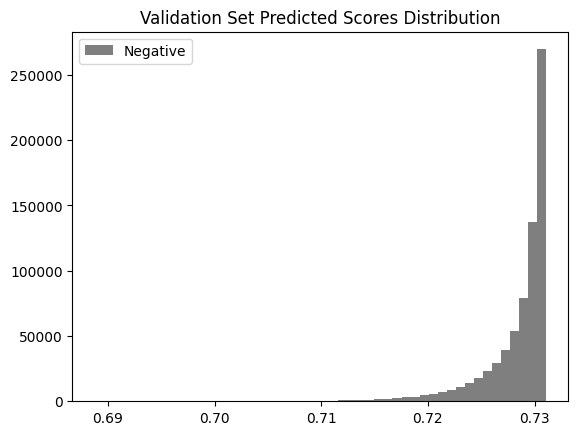

In [10]:
plt.hist(valid_scores[train_labels == 0], bins=50, alpha=0.5, label='Negative', color='black')
plt.title('Validation Set Predicted Scores Distribution')
plt.legend()
plt.show()

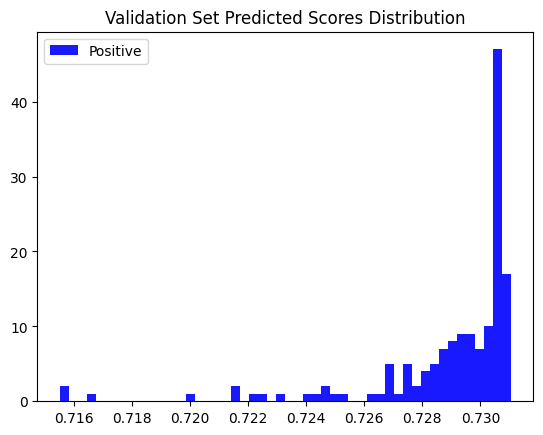

In [11]:
plt.hist(valid_scores[valid_labels == 1], bins=50, alpha=0.9, label='Positive', color='blue')
plt.title('Validation Set Predicted Scores Distribution')
plt.legend()
plt.show()

In [14]:
# Evaluate on train set
train_labels, train_scores, train_auc = evaluate_contrastive_model(model, embeddings, G_train, device)
print(f"\nTrain ROC AUC: {train_auc:.4f}")

: 

: 

: 